# Temporal Fusion Transformer Training
Automated TFT configuration combining exploratory data parsing rules and the PyTorch TFTv2 architecture.

All variables will be evaluated intrinsically by the model's self-contained `VariableSelectionNetwork` so manual PCA and dimensionality drop is ignored.

In [18]:
import os, sys, random, warnings, time, logging
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()} - {torch.cuda.get_device_name(0) if torch.cuda.is_available() else ''}")

# Checkpointing & Logging Setup
OUTPUT_DIR = Path("checkpoints_05_quantile")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = OUTPUT_DIR / f"quantile_training_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.FileHandler(LOG_FILE, encoding="utf-8"),
        logging.StreamHandler(),
    ],
    force=True
)
log = logging.getLogger(__name__)
log.info("Started TFT Pipeline Configuration")

2026-04-13 15:47:54 | Started TFT Pipeline Configuration


PyTorch: 2.6.0+cu124
CUDA: True - NVIDIA RTX A1000


## Configuration Space
All hyperparameters are stored here. Sequence length assumes `4` since financial market sequences change fast (tuned against overfitting).

In [19]:
# TFT Hyperparameters
SEQ_LEN        = 4           
BATCH_SIZE     = 1024        
MAX_TRAIN_SEQ  = None           
MAX_VAL_SEQ    = 500_000
TOP_K_FEATURES = 30
HIDDEN_DIM     = 48          
NUM_HEADS      = 8
DROPOUT        = 0.3         
EMBED_DIM      = 8           
LR             = 1e-3        
WEIGHT_DECAY   = 1e-3        
EPOCHS         = 40          
PATIENCE       = 5
QUANTILES      = [0.1, 0.5, 0.9]
CLIP_NORM      = 1.0

## Data Fetching
Fetching temporal market elements via `polars` into `pandas` DataFrame

In [20]:
log.info("Loading Data...")
DATA_DIR   = Path(r"D:\Gautam\SEM_2\DL")
TRAIN_PATH = DATA_DIR / "TFT" / "data" / "train.parquet"
TEST_PATH  = DATA_DIR / "TFT" / "data" / "test.parquet"

# Using pandas directly or polars if available
train_pl = pl.scan_parquet(str(TRAIN_PATH)).collect()
test_pl  = pl.scan_parquet(str(TEST_PATH)).collect()
train_pd = train_pl.to_pandas()
test_pd  = test_pl.to_pandas()
del train_pl, test_pl

log.info(f"Train Shape: {train_pd.shape} | Test Shape: {test_pd.shape}")

# Define Columns
TARGET_COL  = "y_target"
WEIGHT_COL  = "weight"
TIME_COL    = "ts_index"
ID_COL      = "id"
HORIZON_COL = "horizon"
GROUP_COLS  = [c for c in ["code", "sub_code", "sub_category"] if c in train_pd.columns]

sort_cols = GROUP_COLS + [TIME_COL]
train_pd  = train_pd.sort_values(sort_cols)
test_pd   = test_pd.sort_values(sort_cols)

feature_cols_all = [c for c in train_pd.columns if c not in [TARGET_COL, WEIGHT_COL, ID_COL]]
numeric_cols_all = [c for c in feature_cols_all if pd.api.types.is_numeric_dtype(train_pd[c])]
cat_feature_cols = [c for c in feature_cols_all if c not in numeric_cols_all]

2026-04-13 15:47:59 | Loading Data...
2026-04-13 15:48:00 | Train Shape: (5337414, 94) | Test Shape: (1447107, 92)


## Exploratory Validation Splits and Engineering
Target value normalization against their exact horizons. Uses a logged weight formula matching `tft_model_v2.py` logic.

In [21]:
log.info("Performing chronological split and scaling...")
unique_times = np.sort(train_pd[TIME_COL].unique())
split_time   = unique_times[int(len(unique_times) * 0.8)]

train_df = train_pd.loc[train_pd[TIME_COL] <  split_time].copy()
val_df   = train_pd.loc[train_pd[TIME_COL] >= split_time].copy()
del train_pd

# Use raw targets without standard scaling (to match evaluation metric)
# Use raw weights (clipping strictly negative weights if any exist)
train_df[WEIGHT_COL] = train_df[WEIGHT_COL].clip(lower=0).values
val_df[WEIGHT_COL]   = val_df[WEIGHT_COL].clip(lower=0).values

log.info(f"Selecting Top {TOP_K_FEATURES} Features based on weighted absolute correlation...")
def weighted_abs_corr(x, y, w):
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w)
    if mask.sum() < 10: return 0.0
    x, y, w = x[mask], y[mask], w[mask]
    w_sum = w.sum()
    if w_sum <= 0: return 0.0
    x_mean = np.sum(w * x) / w_sum
    y_mean = np.sum(w * y) / w_sum
    x_center = x - x_mean
    y_center = y - y_mean
    cov = np.sum(w * x_center * y_center) / w_sum
    x_var = np.sum(w * np.square(x_center)) / w_sum
    y_var = np.sum(w * np.square(y_center)) / w_sum
    if x_var <= 0 or y_var <= 0: return 0.0
    return float(abs(cov / np.sqrt(x_var * y_var)))

# Calculate correlation on train_df subset to speed up execution
scores = []
sample_size = min(len(train_df), 800_000)
# taking the most recent sample size since markets drift temporarily
sample_df = train_df.sort_values(TIME_COL).tail(sample_size)
y_vals = sample_df[TARGET_COL].values
w_vals = sample_df[WEIGHT_COL].values

for col in numeric_cols_all:
    c = weighted_abs_corr(sample_df[col].values, y_vals, w_vals)
    scores.append((col, c))
    
scores.sort(key=lambda x: x[1], reverse=True)
top_numeric_cols = [x[0] for x in scores[:TOP_K_FEATURES]]
numeric_cols_all = top_numeric_cols
log.info(f"Selected Top Features: {numeric_cols_all}")

log.info("Handling Missing Values via Imputation & Scaling...")
# Impute numericals with median
num_fill = {c: train_df[c].median() for c in numeric_cols_all}
for c, m in num_fill.items():
    train_df[c] = train_df[c].fillna(m)
    val_df[c]   = val_df[c].fillna(m)
    if c in test_pd.columns: test_pd[c] = test_pd[c].fillna(m)

# Scale Numericals
scaler = StandardScaler()
train_df[numeric_cols_all] = scaler.fit_transform(train_df[numeric_cols_all])
val_df[numeric_cols_all]   = scaler.transform(val_df[numeric_cols_all])
if set(numeric_cols_all).issubset(test_pd.columns):
    test_pd[numeric_cols_all] = scaler.transform(test_pd[numeric_cols_all])

# Categorical Encoding
cat_maps = {}
cat_vocab_sizes = {}
for c in cat_feature_cols:
    vals  = train_df[c].astype(str).fillna("__NA__")
    vocab = {v: i + 1 for i, v in enumerate(sorted(vals.unique()))}
    cat_maps[c]       = vocab
    cat_vocab_sizes[c] = len(vocab) + 1
    train_df[c] = train_df[c].astype(str).map(vocab).fillna(0).astype(np.int64)
    val_df[c]   = val_df[c].astype(str).map(vocab).fillna(0).astype(np.int64)
    if c in test_pd.columns: test_pd[c] = test_pd[c].astype(str).map(vocab).fillna(0).astype(np.int64)

2026-04-13 15:48:04 | Performing chronological split and scaling...
2026-04-13 15:48:06 | Selecting Top 30 Features based on weighted absolute correlation...
2026-04-13 15:48:10 | Selected Top Features: ['feature_ar', 'feature_bz', 'feature_ad', 'feature_cf', 'feature_bt', 'feature_aq', 'feature_l', 'feature_cg', 'feature_bf', 'feature_bv', 'feature_bn', 'feature_ca', 'feature_bh', 'feature_a', 'feature_bs', 'feature_bw', 'feature_bk', 'feature_am', 'feature_ai', 'feature_bo', 'feature_m', 'feature_s', 'feature_u', 'feature_au', 'feature_cd', 'feature_cb', 'feature_n', 'feature_as', 'feature_at', 'feature_ak']
2026-04-13 15:48:10 | Handling Missing Values via Imputation & Scaling...


## Sequence Building
Converting continuous market segments into valid PyTorch `TensorDataset` configurations to feed into the LSTM module.

In [22]:
log.info("Building sequences...")
model_feature_cols = numeric_cols_all + cat_feature_cols

static_feature_names   = [c for c in cat_feature_cols if c in model_feature_cols]
known_future_names     = [c for c in [TIME_COL, HORIZON_COL] if c in model_feature_cols and c not in static_feature_names]
# Dimensionality reduction handled intrinsically by Variable Selection Network (VSN) below over observed features
observed_feature_names = [c for c in model_feature_cols if c not in static_feature_names]

static_idx       = [model_feature_cols.index(c) for c in static_feature_names]
known_future_idx = [model_feature_cols.index(c) for c in known_future_names]
observed_idx     = [model_feature_cols.index(c) for c in observed_feature_names]

def make_sequences(df, seq_len, feature_cols, target_col, weight_col=None, group_cols=None, time_col="ts_index", max_samples=None):
    X, y, w = [], [], []
    if group_cols and all(c in df.columns for c in group_cols):
        groups   = df.groupby(group_cols, sort=False)
        iterable = (g.sort_values(time_col) for _, g in groups)
    else:
        iterable = [df.sort_values(time_col)]

    count = 0
    for gdf in iterable:
        vals = gdf[feature_cols].values.astype(np.float32)
        yt   = gdf[target_col].values.astype(np.float32)
        wt   = (gdf[weight_col].values.astype(np.float32) if weight_col else np.ones(len(gdf), dtype=np.float32))
        if len(gdf) <= seq_len: continue
        for i in range(seq_len, len(gdf)):
            if max_samples is None or count < max_samples:
                X.append(vals[i - seq_len:i])
                y.append(yt[i])
                w.append(wt[i])
            else:
                j = random.randint(0, count)
                if j < max_samples:
                    X[j] = vals[i - seq_len:i]
                    y[j] = yt[i]
                    w[j] = wt[i]
            count += 1
    return np.asarray(X), np.asarray(y), np.asarray(w)

X_train, y_train, w_train = make_sequences(train_df, SEQ_LEN, model_feature_cols, TARGET_COL, WEIGHT_COL, GROUP_COLS, TIME_COL, MAX_TRAIN_SEQ)
X_val, y_val, w_val = make_sequences(val_df, SEQ_LEN, model_feature_cols, TARGET_COL, WEIGHT_COL, GROUP_COLS, TIME_COL, MAX_VAL_SEQ)
log.info(f"X_train: {X_train.shape} | X_val: {X_val.shape}")

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32), torch.tensor(w_train, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32), torch.tensor(w_val, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0)

2026-04-13 15:48:23 | Building sequences...
2026-04-13 15:48:34 | X_train: (4092929, 4, 33) | X_val: (500000, 4, 33)


## Optimization Goals
Using `Weighted Mean Squared Error` against the observed weights of different assets.

In [23]:
def quantile_loss(y_true, y_pred, w, quantiles=[0.1, 0.5, 0.9]):
    # y_true shape: [B], y_pred shape: [B, 3]
    errors = y_true.unsqueeze(-1) - y_pred # [B, 3]
    q_tensor = torch.tensor(quantiles, device=y_pred.device) # [3]
    losses = torch.max((q_tensor - 1) * errors, q_tensor * errors)
    # Average across everything, weighted by the sample weight
    return torch.mean(w.unsqueeze(-1) * losses)

## Temporal Fusion Transformer (v2)
An optimized, low-parameter model designed not to overfit. Combines `MultiheadAttention`, `GLU`, `GRN`, and `VariableSelectionNetwork` modules.

In [24]:
class GLU(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc   = nn.Linear(dim, dim)
        self.gate = nn.Linear(dim, dim)
    def forward(self, x):
        return self.fc(x) * torch.sigmoid(self.gate(x))

class GRN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim=None, dropout=0.1, context_dim=None):
        super().__init__()
        out_dim = out_dim or in_dim
        self.fc1        = nn.Linear(in_dim, hidden_dim)
        self.context_fc = nn.Linear(context_dim, hidden_dim, bias=False) if context_dim else None
        self.elu     = nn.ELU()
        self.fc2     = nn.Linear(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        self.glu     = GLU(out_dim)
        self.skip    = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        self.norm    = nn.LayerNorm(out_dim)
    def forward(self, x, context=None):
        h = self.fc1(x)
        if self.context_fc is not None and context is not None:
            while context.dim() < h.dim(): context = context.unsqueeze(1)
            h = h + self.context_fc(context)
        h = self.elu(h)
        h = self.dropout(h)
        h = self.fc2(h)
        h = self.glu(h)
        return self.norm(h + self.skip(x))

class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_vars, hidden_dim, dropout=0.1, context_dim=None):
        super().__init__()
        self.num_vars = num_vars
        self.var_grns = nn.ModuleList([GRN(1, hidden_dim, hidden_dim, dropout) for _ in range(num_vars)])
        self.weight_grn = GRN(num_vars, hidden_dim, num_vars, dropout, context_dim=context_dim)
    def forward(self, x, context=None):
        is_temporal = x.dim() == 3
        if self.num_vars == 0:
            if is_temporal: return torch.zeros(x.size(0), x.size(1), 1, device=x.device), None
            return torch.zeros(x.size(0), 1, device=x.device), None
        if is_temporal:
            transformed = [self.var_grns[i](x[..., i:i+1]) for i in range(self.num_vars)]
            transformed = torch.stack(transformed, dim=-2)
            weights = self.weight_grn(x, context)
            weights = torch.softmax(weights, dim=-1).unsqueeze(-1)
            return (transformed * weights).sum(dim=-2), weights.squeeze(-1)
        else:
            transformed = [self.var_grns[i](x[:, i:i+1]) for i in range(self.num_vars)]
            transformed = torch.stack(transformed, dim=1)
            weights = self.weight_grn(x, context)
            weights = torch.softmax(weights, dim=-1).unsqueeze(-1)
            return (transformed * weights).sum(dim=1), weights.squeeze(-1)

class TFTv2(nn.Module):
    def __init__(self, static_idx, known_future_idx, observed_idx, cat_feature_indices, cat_vocab_sizes_list, hidden_dim=32, num_heads=2, dropout=0.35, embed_dim=8):
        super().__init__()
        self.cat_feature_indices = cat_feature_indices
        self.hidden_dim = hidden_dim
        self.cat_embeddings = nn.ModuleList([nn.Embedding(vs, embed_dim, padding_idx=0) for vs in cat_vocab_sizes_list])
        n_cont_observed  = len([i for i in observed_idx if i not in cat_feature_indices])
        static_input_dim = len(cat_feature_indices) * embed_dim
        self.static_fc = nn.Linear(static_input_dim, hidden_dim)
        self.static_context_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.observed_idx = observed_idx
        self.known_future_idx = known_future_idx
        self.observed_vsn = VariableSelectionNetwork(n_cont_observed, hidden_dim, dropout, context_dim=hidden_dim)
        self.known_vsn = VariableSelectionNetwork(len(known_future_idx), hidden_dim, dropout, context_dim=hidden_dim) if len(known_future_idx) > 0 else None
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.post_lstm_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.static_enrichment = GRN(hidden_dim, hidden_dim, hidden_dim, dropout, context_dim=hidden_dim)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.post_attn_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.position_grn  = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)
        self.output_head = nn.Linear(hidden_dim, len(QUANTILES))
    def _causal_mask(self, t, device):
        return torch.triu(torch.ones(t, t, device=device), diagonal=1).bool()
    def forward(self, x):
        b, t, _ = x.shape
        if self.cat_feature_indices:
            cat_embeds = []
            for k, idx in enumerate(self.cat_feature_indices):
                cat_input = x[:, 0, idx].long().clamp(min=0)
                cat_embeds.append(self.cat_embeddings[k](cat_input))
            static_in  = torch.cat(cat_embeds, dim=-1)
            static_ctx = torch.relu(self.static_fc(static_in))
        else:
            static_ctx = torch.zeros(b, self.hidden_dim, device=x.device)
        static_ctx = self.static_context_grn(static_ctx)
        cont_idx = [i for i in self.observed_idx if i not in self.cat_feature_indices]
        x_obs = x[:, :, cont_idx]
        obs_repr, _ = self.observed_vsn(x_obs, context=static_ctx)
        if self.known_vsn is not None:
            x_known = x[:, :, self.known_future_idx]
            known_repr, _ = self.known_vsn(x_known, context=static_ctx)
            temporal_in = obs_repr + known_repr
        else:
            temporal_in = obs_repr
        lstm_out, _ = self.lstm(temporal_in)
        temporal = self.post_lstm_grn(lstm_out)
        temporal = self.static_enrichment(temporal, context=static_ctx)
        mask = self._causal_mask(t, x.device)
        attn_out, _ = self.attn(temporal, temporal, temporal, attn_mask=mask, need_weights=False)
        temporal = self.post_attn_grn(temporal + attn_out)
        temporal = self.position_grn(temporal)
        return self.output_head(temporal[:, -1, :])

cat_indices_in_fv = [model_feature_cols.index(c) for c in cat_feature_cols]
cat_vsizes        = [cat_vocab_sizes[c] for c in cat_feature_cols]

model = TFTv2(
    static_idx           = static_idx,
    known_future_idx     = known_future_idx,
    observed_idx         = observed_idx,
    cat_feature_indices  = cat_indices_in_fv,
    cat_vocab_sizes_list = cat_vsizes,
    hidden_dim  = HIDDEN_DIM,
    num_heads   = NUM_HEADS,
    dropout     = DROPOUT,
    embed_dim   = EMBED_DIM,
).to(DEVICE)
log.info(f"Model initialized. Parameters: {sum(p.numel() for p in model.parameters()):,}")

2026-04-13 15:48:41 | Model initialized. Parameters: 308,305


## Training Execution
Standard optimization loop against the validation boundaries. Checkpoints are automatically saved iteratively using `torch.save` over each epoch to allow ensemble creation later.

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
WARMUP_EPOCHS = 3
def get_lr(epoch):
    if epoch < WARMUP_EPOCHS: return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, get_lr)

train_losses, val_losses, val_rmses = [], [], []
best_val_loss = float('inf')

log.info("Starting Training...")
for epoch in range(1, EPOCHS + 1):
    t_ep = time.time()
    model.train()
    batch_losses = []
    
    for xb, yb, wb in train_loader:
        xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = quantile_loss(yb, pred, wb, QUANTILES)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()
        batch_losses.append(loss.item())
        
    scheduler.step()
    ep_train_loss = np.mean(batch_losses)
    train_losses.append(ep_train_loss)

    # Validation Phase
    model.eval()
    val_batch_losses = []
    val_sq_err_sum = 0.0
    val_w_sum = 0.0
    with torch.no_grad():
        for xb, yb, wb in val_loader:
            xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
            pred = model(xb)
            vloss = quantile_loss(yb, pred, wb, QUANTILES)
            val_batch_losses.append(vloss.item())
            # RMSE via P50 (median) as point estimate
            p50 = pred[:, 1]
            val_sq_err_sum += (wb * (yb - p50) ** 2).sum().item()
            val_w_sum += wb.sum().item()
    
    ep_val_loss = np.mean(val_batch_losses)
    val_losses.append(ep_val_loss)
    ep_val_rmse = np.sqrt(val_sq_err_sum / max(val_w_sum, 1e-12))
    val_rmses.append(ep_val_rmse)
    dt = time.time() - t_ep
    
    # Save Epoch Checkpoint
    checkpoint_path = OUTPUT_DIR / f'checkpoint_epoch_{epoch:02d}.pt'
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': ep_val_loss,
        'val_rmse': ep_val_rmse,
    }, checkpoint_path)
    
    tag = " *" if ep_val_loss < best_val_loss else ""
    best_val_loss = min(best_val_loss, ep_val_loss)
    log.info(f"Epoch {epoch:02d} | Train Loss: {ep_train_loss:.6f} | Val Loss: {ep_val_loss:.6f} | Val RMSE(P50): {ep_val_rmse:.6f} | Time: {dt:.1f}s | Saved: {checkpoint_path.name}{tag}")

log.info("Training Completed!")

## Validating Overfitting via Gradients
Generating epoch trajectory plot mapping temporal decay visually.

In [25]:
# ============================================================
# Compute Validation RMSE from saved checkpoints (no retraining)
# ============================================================
log.info("Computing Validation RMSE from saved checkpoints...")

checkpoint_files = sorted(OUTPUT_DIR.glob('checkpoint_epoch_*.pt'))
log.info(f"Found {len(checkpoint_files)} checkpoints")

val_rmses = []
val_losses_recomputed = []

for ckpt_path in checkpoint_files:
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    
    epoch_num = ckpt['epoch']
    sq_err_sum = 0.0
    w_sum = 0.0
    batch_losses = []
    
    with torch.no_grad():
        for xb, yb, wb in val_loader:
            xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
            pred = model(xb)
            vloss = quantile_loss(yb, pred, wb, QUANTILES)
            batch_losses.append(vloss.item())
            # RMSE via P50 (median) as point estimate
            p50 = pred[:, 1]
            sq_err_sum += (wb * (yb - p50) ** 2).sum().item()
            w_sum += wb.sum().item()
    
    ep_val_loss = np.mean(batch_losses)
    ep_val_rmse = np.sqrt(sq_err_sum / max(w_sum, 1e-12))
    val_rmses.append(ep_val_rmse)
    val_losses_recomputed.append(ep_val_loss)
    log.info(f"Epoch {epoch_num:02d} | Val Loss: {ep_val_loss:.6f} | Val RMSE(P50): {ep_val_rmse:.6f}")

log.info(f"Best Val RMSE(P50): {min(val_rmses):.6f} at Epoch {val_rmses.index(min(val_rmses)) + 1}")
log.info("Done!")

2026-04-13 15:48:49 | Computing Validation RMSE from saved checkpoints...
2026-04-13 15:48:49 | Found 40 checkpoints
2026-04-13 15:48:57 | Epoch 01 | Val Loss: 12591.412917 | Val RMSE(P50): 0.005440
2026-04-13 15:49:04 | Epoch 02 | Val Loss: 15631.291514 | Val RMSE(P50): 0.007338
2026-04-13 15:49:12 | Epoch 03 | Val Loss: 32640.249230 | Val RMSE(P50): 0.002848
2026-04-13 15:49:19 | Epoch 04 | Val Loss: 10492.456130 | Val RMSE(P50): 0.004720
2026-04-13 15:49:27 | Epoch 05 | Val Loss: 6776.765439 | Val RMSE(P50): 0.003552
2026-04-13 15:49:34 | Epoch 06 | Val Loss: 2770.878538 | Val RMSE(P50): 0.003166
2026-04-13 15:49:43 | Epoch 07 | Val Loss: 2992.508425 | Val RMSE(P50): 0.002807
2026-04-13 15:49:51 | Epoch 08 | Val Loss: 3668.852036 | Val RMSE(P50): 0.002672
2026-04-13 15:50:00 | Epoch 09 | Val Loss: 3628.239003 | Val RMSE(P50): 0.002994
2026-04-13 15:50:08 | Epoch 10 | Val Loss: 2750.227973 | Val RMSE(P50): 0.002763
2026-04-13 15:50:16 | Epoch 11 | Val Loss: 2629.289459 | Val RMSE(P50

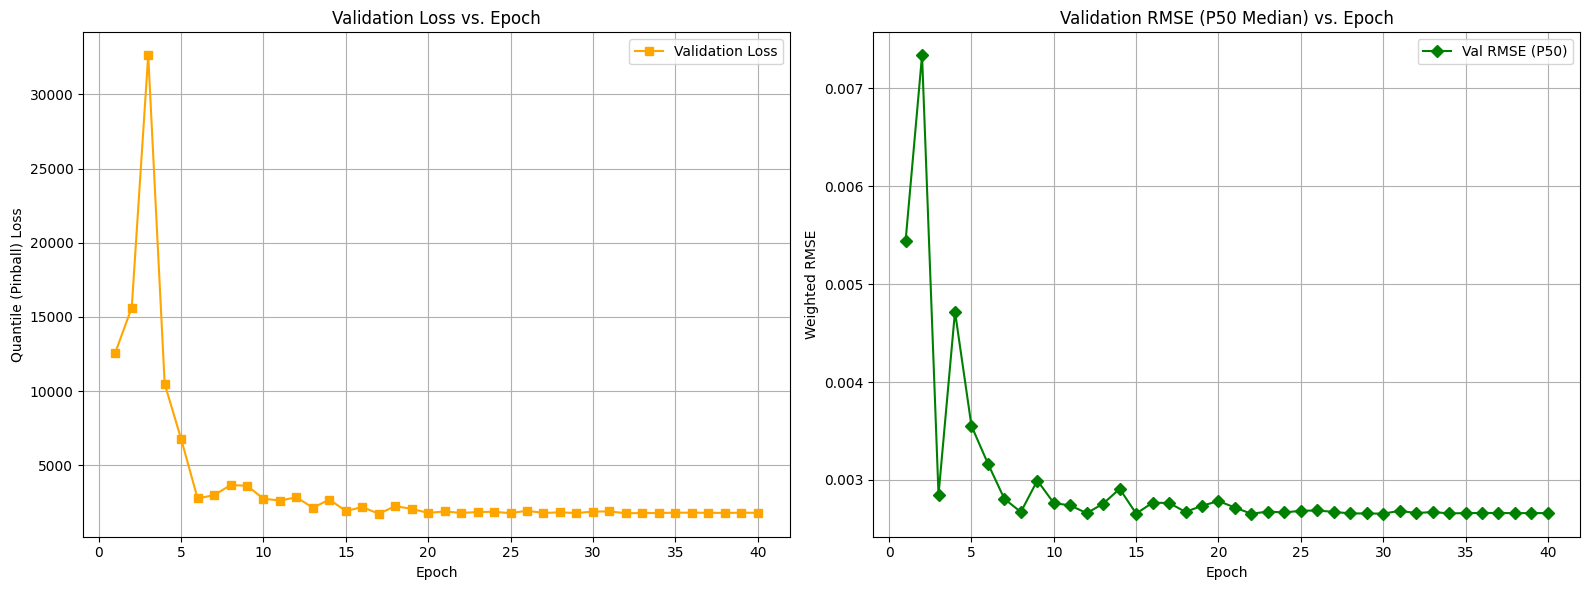

2026-04-13 15:54:22 | Loss & RMSE plot saved to checkpoints_05_quantile\loss_rmse_vs_epoch.png


In [26]:
# Plot Loss and RMSE vs Epoch
n_epochs = len(val_rmses)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Quantile Loss
if 'train_losses' in dir() and len(train_losses) == n_epochs:
    ax1.plot(range(1, n_epochs + 1), train_losses, label='Train Loss', marker='o', color='blue')
ax1.plot(range(1, n_epochs + 1), val_losses_recomputed, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Validation Loss vs. Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Quantile (Pinball) Loss')
ax1.legend()
ax1.grid()

# Right: Validation RMSE (P50)
ax2.plot(range(1, n_epochs + 1), val_rmses, label='Val RMSE (P50)', marker='D', color='green')
ax2.set_title('Validation RMSE (P50 Median) vs. Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Weighted RMSE')
ax2.legend()
ax2.grid()

plt.tight_layout()
plot_path = OUTPUT_DIR / "loss_rmse_vs_epoch.png"
plt.savefig(plot_path)
plt.show()
log.info(f"Loss & RMSE plot saved to {plot_path}")

2026-04-13 15:59:25 | Computing Kaggle Competition Score for each checkpoint...
2026-04-13 15:59:33 | Epoch 01 | Competition Score: 0.000000
2026-04-13 15:59:41 | Epoch 02 | Competition Score: 0.000000
2026-04-13 15:59:49 | Epoch 03 | Competition Score: 0.000000
2026-04-13 15:59:57 | Epoch 04 | Competition Score: 0.000000
2026-04-13 16:00:05 | Epoch 05 | Competition Score: 0.000000
2026-04-13 16:00:13 | Epoch 06 | Competition Score: 0.000000
2026-04-13 16:00:20 | Epoch 07 | Competition Score: 0.000000
2026-04-13 16:00:28 | Epoch 08 | Competition Score: 0.000000
2026-04-13 16:00:35 | Epoch 09 | Competition Score: 0.000000
2026-04-13 16:00:43 | Epoch 10 | Competition Score: 0.000000
2026-04-13 16:00:51 | Epoch 11 | Competition Score: 0.000000
2026-04-13 16:00:58 | Epoch 12 | Competition Score: 0.000000
2026-04-13 16:01:06 | Epoch 13 | Competition Score: 0.000000
2026-04-13 16:01:13 | Epoch 14 | Competition Score: 0.000000
2026-04-13 16:01:21 | Epoch 15 | Competition Score: 0.000000
2026-

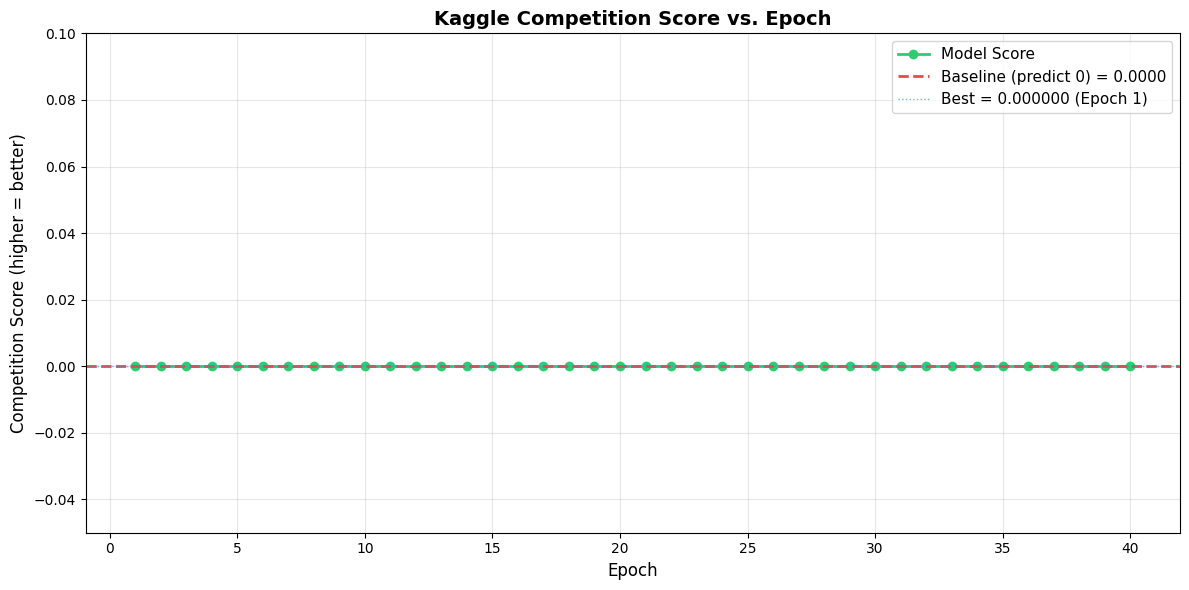

2026-04-13 16:04:44 | Competition score plot saved to checkpoints_05_quantile\competition_score_vs_epoch.png


In [30]:
# ============================================================
# Kaggle Competition Metric: weighted_rmse_score
# https://www.kaggle.com/competitions/ts-forecasting
# Score ranges from 0.0 (bad) to 1.0 (perfect)
# Predicting all zeros = score of exactly 0.0
# ============================================================

def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))

def weighted_rmse_score(y_target, y_pred, w) -> float:
    denom = np.sum(w * y_target ** 2)
    ratio = np.sum(w * (y_target - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    val = 1.0 - clipped
    return float(np.sqrt(val))

# --- Evaluate each checkpoint with the competition metric ---
log.info("Computing Kaggle Competition Score for each checkpoint...")

checkpoint_files = sorted(OUTPUT_DIR.glob('checkpoint_epoch_*.pt'))
comp_scores = []

for ckpt_path in checkpoint_files:
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    epoch_num = ckpt['epoch']
    
    all_preds = []
    with torch.no_grad():
        for xb, yb, wb in val_loader:
            xb = xb.to(DEVICE)
            pred = model(xb)
            p50 = pred[:, 1].cpu().numpy()  # median as point estimate
            all_preds.append(p50)
    
    y_pred_all = np.concatenate(all_preds)
    score = weighted_rmse_score(y_val, y_pred_all, w_val)
    comp_scores.append(score)
    log.info(f"Epoch {epoch_num:02d} | Competition Score: {score:.6f}")

# --- Summary ---
best_score = max(comp_scores)
best_epoch = comp_scores.index(best_score) + 1
baseline_score = weighted_rmse_score(y_val, np.zeros_like(y_val), w_val)

log.info("=" * 60)
log.info("KAGGLE COMPETITION METRIC SUMMARY")
log.info("=" * 60)
log.info(f"Baseline Score (predict 0):    {baseline_score:.6f}")
log.info(f"Best Model Score:              {best_score:.6f}  (Epoch {best_epoch})")
log.info(f"Worst Model Score:             {min(comp_scores):.6f}  (Epoch {comp_scores.index(min(comp_scores)) + 1})")
log.info("=" * 60)

# --- Plot competition score vs epoch ---
fig, ax = plt.subplots(figsize=(12, 6))
epochs_range = range(1, len(comp_scores) + 1)
ax.plot(epochs_range, comp_scores, marker='o', color='#2ecc71', linewidth=2, label='Model Score')
ax.axhline(y=baseline_score, color='#e74c3c', linestyle='--', linewidth=2, label=f'Baseline (predict 0) = {baseline_score:.4f}')
ax.axhline(y=best_score, color='#3498db', linestyle=':', linewidth=1, alpha=0.7, label=f'Best = {best_score:.6f} (Epoch {best_epoch})')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Competition Score (higher = better)', fontsize=12)
ax.set_title('Kaggle Competition Score vs. Epoch', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(bottom=-0.05, top=max(best_score * 1.3, 0.1))

plt.tight_layout()
plot_path = OUTPUT_DIR / "competition_score_vs_epoch.png"
plt.savefig(plot_path, dpi=150)
plt.show()
log.info(f"Competition score plot saved to {plot_path}")

In [31]:
# ============================================================
# DIAGNOSTIC: Why is competition score = 0?
# ============================================================
# Load best checkpoint (e.g., epoch 22 had best RMSE)
best_ckpt_path = sorted(OUTPUT_DIR.glob('checkpoint_epoch_*.pt'))[21]  # epoch 22 (0-indexed=21)
ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
log.info(f"Loaded {best_ckpt_path.name}")

# Collect all predictions
all_preds = []
with torch.no_grad():
    for xb, yb, wb in val_loader:
        xb = xb.to(DEVICE)
        pred = model(xb)
        p50 = pred[:, 1].cpu().numpy()
        all_preds.append(p50)

y_pred_all = np.concatenate(all_preds)

# --- Raw metric components ---
numerator = np.sum(w_val * (y_val - y_pred_all) ** 2)
denominator = np.sum(w_val * y_val ** 2)
ratio = numerator / denominator

log.info("")
log.info("=" * 60)
log.info("DIAGNOSTIC ANALYSIS")
log.info("=" * 60)
log.info(f"Numerator   sum(w*(y-ŷ)²) = {numerator:.6f}")
log.info(f"Denominator sum(w*y²)      = {denominator:.6f}")
log.info(f"Ratio                      = {ratio:.6f}")
log.info(f"Score > 0 needs ratio < 1.0")
log.info("")

# --- Baseline comparison ---
baseline_numerator = np.sum(w_val * y_val ** 2)  # when ŷ=0, (y-0)²=y²
log.info(f"Baseline numerator (ŷ=0)   = {baseline_numerator:.6f}")
log.info(f"Model is {ratio:.4f}x the baseline (need < 1.0x)")
log.info("")

# --- Prediction statistics ---
log.info("--- Prediction Statistics ---")
log.info(f"y_val   : mean={y_val.mean():.8f}, std={y_val.std():.8f}, min={y_val.min():.8f}, max={y_val.max():.8f}")
log.info(f"y_pred  : mean={y_pred_all.mean():.8f}, std={y_pred_all.std():.8f}, min={y_pred_all.min():.8f}, max={y_pred_all.max():.8f}")
log.info(f"w_val   : mean={w_val.mean():.8f}, std={w_val.std():.8f}, min={w_val.min():.8f}, max={w_val.max():.8f}")
log.info("")

# --- Correlation ---
corr = np.corrcoef(y_val, y_pred_all)[0, 1]
log.info(f"Correlation(y, ŷ): {corr:.6f}")

# --- Weighted correlation ---
w_norm = w_val / w_val.sum()
y_wm = np.sum(w_norm * y_val)
p_wm = np.sum(w_norm * y_pred_all)
w_cov = np.sum(w_norm * (y_val - y_wm) * (y_pred_all - p_wm))
w_std_y = np.sqrt(np.sum(w_norm * (y_val - y_wm)**2))
w_std_p = np.sqrt(np.sum(w_norm * (y_pred_all - p_wm)**2))
w_corr = w_cov / max(w_std_y * w_std_p, 1e-12)
log.info(f"Weighted Correlation(y, ŷ): {w_corr:.6f}")
log.info("")

# --- Sign accuracy ---
sign_match = np.mean(np.sign(y_val) == np.sign(y_pred_all))
log.info(f"Sign accuracy: {sign_match:.4f} (0.5 = random)")

# --- Magnitude comparison ---
log.info(f"Pred/Target magnitude ratio: {np.abs(y_pred_all).mean() / max(np.abs(y_val).mean(), 1e-12):.4f}")
log.info(f"  (> 1 means predictions are too large, adding noise)")
log.info("")

# --- What if we scale predictions down? ---
log.info("--- What if we scale predictions? ---")
for scale in [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]:
    scaled_pred = y_pred_all * scale
    score = weighted_rmse_score(y_val, scaled_pred, w_val)
    log.info(f"  scale={scale:.2f} -> score={score:.6f}")
log.info("=" * 60)

2026-04-13 16:06:31 | Loaded checkpoint_epoch_22.pt
2026-04-13 16:06:39 | 
2026-04-13 16:06:39 | ============================================================
2026-04-13 16:06:39 | DIAGNOSTIC ANALYSIS
2026-04-13 16:06:39 | ============================================================
2026-04-13 16:06:39 | Numerator   sum(w*(y-ŷ)²) = 37368920.000000
2026-04-13 16:06:39 | Denominator sum(w*y²)      = 37261224.000000
2026-04-13 16:06:39 | Ratio                      = 1.002890
2026-04-13 16:06:39 | Score > 0 needs ratio < 1.0
2026-04-13 16:06:39 | 
2026-04-13 16:06:39 | Baseline numerator (ŷ=0)   = 37261224.000000
2026-04-13 16:06:39 | Model is 1.0029x the baseline (need < 1.0x)
2026-04-13 16:06:39 | 
2026-04-13 16:06:39 | --- Prediction Statistics ---
2026-04-13 16:06:39 | y_val   : mean=-0.32154211, std=27.55908012, min=-776.58392334, max=878.56762695
2026-04-13 16:06:39 | y_pred  : mean=-0.00693903, std=0.00850013, min=-0.02241818, max=0.03415296
2026-04-13 16:06:39 | w_val   : mean=10611

2026-04-13 16:10:37 | Analytical optimal scale: 0.4337
2026-04-13 16:10:37 | Fine-grained scale search...
2026-04-13 16:10:39 | 
2026-04-13 16:10:39 | ============================================================
2026-04-13 16:10:39 | OPTIMAL SCALE FOUND: 0.4340
2026-04-13 16:10:39 | BEST COMPETITION SCORE: 0.064028
2026-04-13 16:10:39 | ============================================================


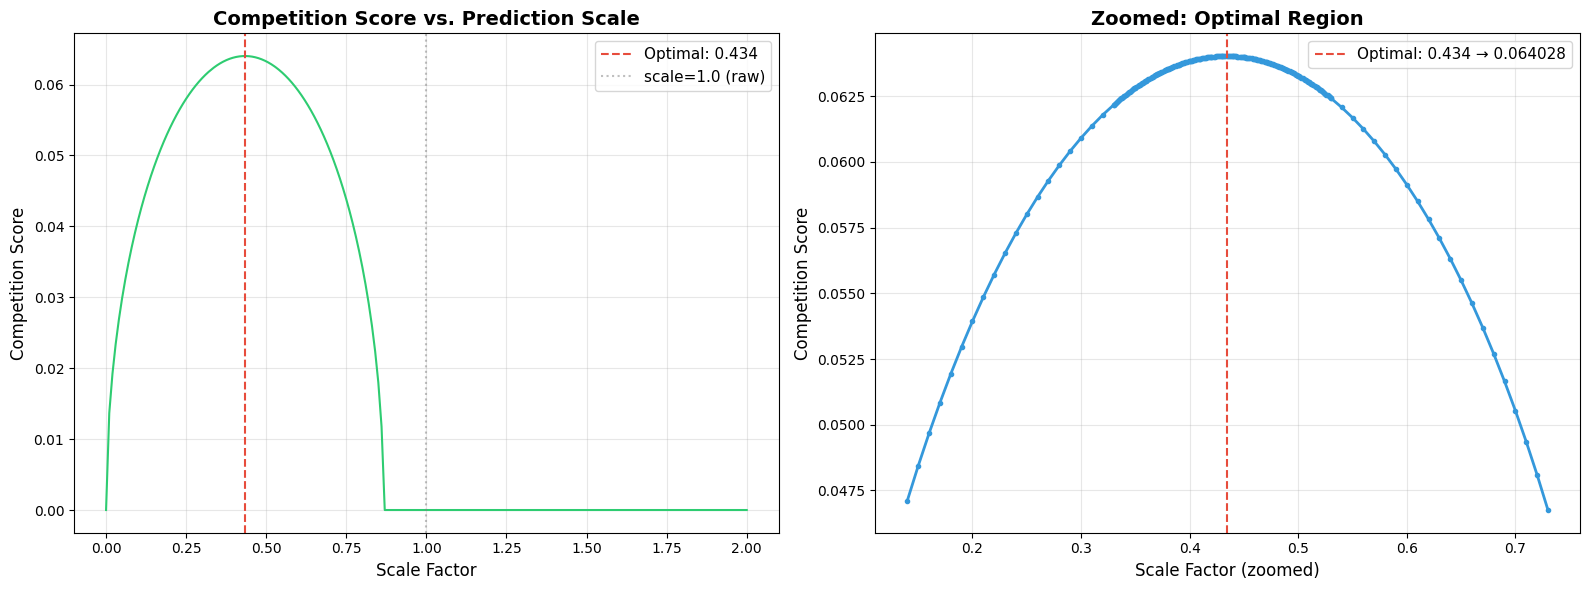

2026-04-13 16:10:39 | Plot saved to checkpoints_05_quantile\optimal_scale_search.png
2026-04-13 16:10:39 | 
2026-04-13 16:10:39 | Evaluating ALL checkpoints at optimal scale...
2026-04-13 16:10:47 | Epoch 01 | Fixed scale(0.43): 0.000000 | Own optimal scale(-0.00): 0.006918 ***
2026-04-13 16:10:55 | Epoch 02 | Fixed scale(0.43): 0.000000 | Own optimal scale(0.00): 0.007580 ***
2026-04-13 16:11:02 | Epoch 03 | Fixed scale(0.43): 0.000000 | Own optimal scale(0.02): 0.009531 ***
2026-04-13 16:11:10 | Epoch 04 | Fixed scale(0.43): 0.000000 | Own optimal scale(-0.00): 0.002697
2026-04-13 16:11:17 | Epoch 05 | Fixed scale(0.43): 0.000000 | Own optimal scale(0.02): 0.013707 ***
2026-04-13 16:11:25 | Epoch 06 | Fixed scale(0.43): 0.000000 | Own optimal scale(0.02): 0.014921 ***
2026-04-13 16:11:33 | Epoch 07 | Fixed scale(0.43): 0.000000 | Own optimal scale(0.04): 0.014290
2026-04-13 16:11:41 | Epoch 08 | Fixed scale(0.43): 0.000000 | Own optimal scale(0.08): 0.010748
2026-04-13 16:11:50 | Epo

In [32]:
# ============================================================
# Find OPTIMAL scaling factor for predictions
# ============================================================

# --- Analytical optimal scale ---
# Minimizing ratio = sum(w*(y - s*ŷ)²) / sum(w*y²)
# Optimal s = sum(w*y*ŷ) / sum(w*ŷ²)
analytical_scale = np.sum(w_val * y_val * y_pred_all) / np.sum(w_val * y_pred_all**2)
log.info(f"Analytical optimal scale: {analytical_scale:.4f}")

# --- Fine grid search ---
log.info("Fine-grained scale search...")
best_score = -1
best_scale = 0
results = []

# Search across wide range first
for scale in np.arange(0.0, 2.01, 0.01):
    scaled = y_pred_all * scale
    score = weighted_rmse_score(y_val, scaled, w_val)
    results.append((scale, score))
    if score > best_score:
        best_score = score
        best_scale = scale

# Fine-tune around the best
for scale in np.arange(max(0, best_scale - 0.1), best_scale + 0.1, 0.001):
    scaled = y_pred_all * scale
    score = weighted_rmse_score(y_val, scaled, w_val)
    results.append((scale, score))
    if score > best_score:
        best_score = score
        best_scale = scale

log.info(f"")
log.info("=" * 60)
log.info(f"OPTIMAL SCALE FOUND: {best_scale:.4f}")
log.info(f"BEST COMPETITION SCORE: {best_score:.6f}")
log.info("=" * 60)

# --- Plot score vs scale ---
results.sort(key=lambda x: x[0])
scales = [r[0] for r in results]
scores = [r[1] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Full range
ax1.plot(scales, scores, color='#2ecc71', linewidth=1.5)
ax1.axvline(x=best_scale, color='#e74c3c', linestyle='--', label=f'Optimal: {best_scale:.3f}')
ax1.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5, label='scale=1.0 (raw)')
ax1.set_xlabel('Scale Factor', fontsize=12)
ax1.set_ylabel('Competition Score', fontsize=12)
ax1.set_title('Competition Score vs. Prediction Scale', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Zoomed around optimal
zoom_mask = [(s, sc) for s, sc in zip(scales, scores) if abs(s - best_scale) < 0.3]
ax2.plot([z[0] for z in zoom_mask], [z[1] for z in zoom_mask], color='#3498db', linewidth=2, marker='.')
ax2.axvline(x=best_scale, color='#e74c3c', linestyle='--', label=f'Optimal: {best_scale:.3f} → {best_score:.6f}')
ax2.set_xlabel('Scale Factor (zoomed)', fontsize=12)
ax2.set_ylabel('Competition Score', fontsize=12)
ax2.set_title('Zoomed: Optimal Region', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plot_path = OUTPUT_DIR / "optimal_scale_search.png"
plt.savefig(plot_path, dpi=150)
plt.show()
log.info(f"Plot saved to {plot_path}")

# --- Check all checkpoints at optimal scale ---
log.info("")
log.info("Evaluating ALL checkpoints at optimal scale...")
best_overall_score = -1
best_overall_epoch = 0

for ckpt_path in sorted(OUTPUT_DIR.glob('checkpoint_epoch_*.pt')):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    epoch_num = ckpt['epoch']
    
    preds = []
    with torch.no_grad():
        for xb, yb, wb in val_loader:
            xb = xb.to(DEVICE)
            pred = model(xb)
            p50 = pred[:, 1].cpu().numpy()
            preds.append(p50)
    
    y_pred = np.concatenate(preds)
    
    # Apply optimal scale
    scaled = y_pred * best_scale
    score = weighted_rmse_score(y_val, scaled, w_val)
    
    # Also find per-epoch optimal scale
    ep_opt_scale = np.sum(w_val * y_val * y_pred) / max(np.sum(w_val * y_pred**2), 1e-12)
    ep_opt_score = weighted_rmse_score(y_val, y_pred * ep_opt_scale, w_val)
    
    tag = ""
    if ep_opt_score > best_overall_score:
        best_overall_score = ep_opt_score
        best_overall_epoch = epoch_num
        tag = " ***"
    
    log.info(f"Epoch {epoch_num:02d} | Fixed scale({best_scale:.2f}): {score:.6f} | Own optimal scale({ep_opt_scale:.2f}): {ep_opt_score:.6f}{tag}")

log.info("")
log.info("=" * 60)
log.info(f"BEST OVERALL: Epoch {best_overall_epoch:02d} → Score {best_overall_score:.6f}")
log.info("=" * 60)

2026-04-13 16:23:29 | Loaded checkpoint_epoch_34.pt for quantile calibration analysis
2026-04-13 16:23:37 | Validation samples: 500,000
2026-04-13 16:23:37 | 
2026-04-13 16:23:37 | ============================================================
2026-04-13 16:23:37 | QUANTILE CALIBRATION
2026-04-13 16:23:37 | ============================================================
2026-04-13 16:23:37 | Quantile     Expected     Actual       Weighted     Status
2026-04-13 16:23:37 | ------------------------------------------------------------
2026-04-13 16:23:37 | P10          10.0%        28.0%       8.2%       Poorly calibrated
2026-04-13 16:23:37 | P50          50.0%        51.3%       46.5%       Well calibrated
2026-04-13 16:23:37 | P90          90.0%        73.8%       85.8%       Poorly calibrated
2026-04-13 16:23:37 | 
2026-04-13 16:23:37 | ============================================================
2026-04-13 16:23:37 | PREDICTION INTERVAL COVERAGE (P10 to P90)
2026-04-13 16:23:37 | =========

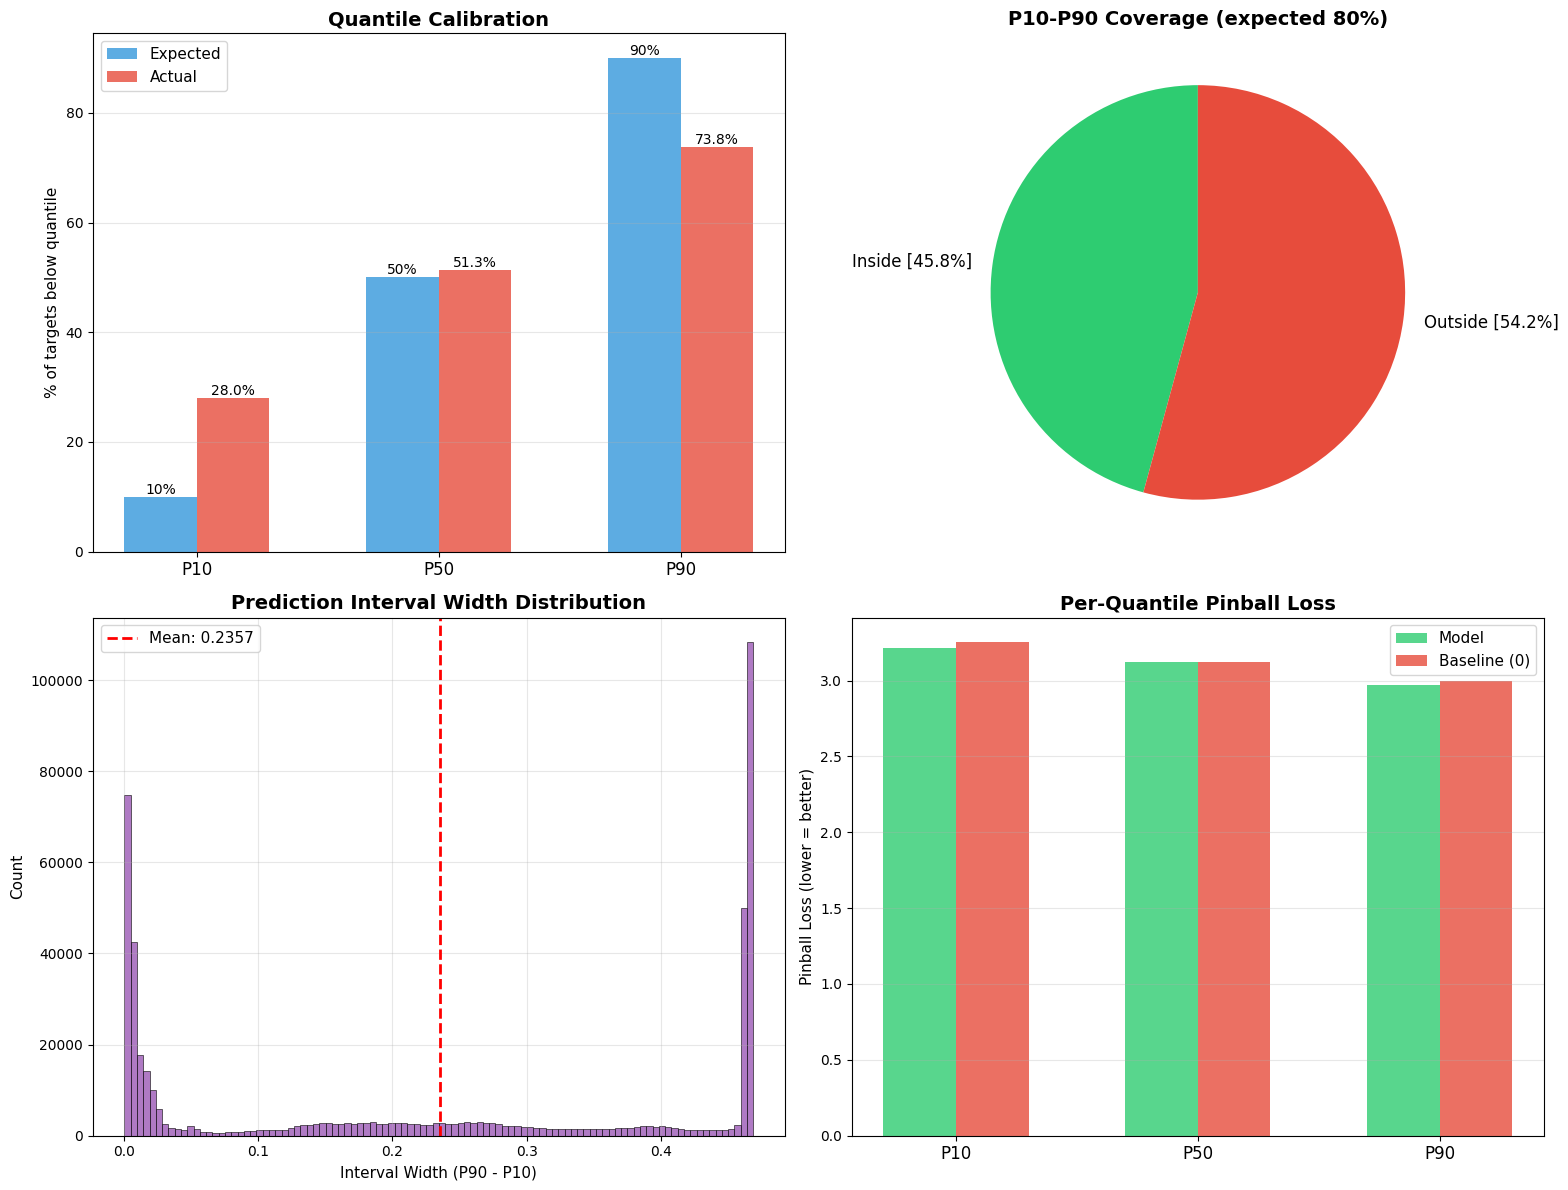

2026-04-13 16:23:38 | 
2026-04-13 16:23:38 | Calibration analysis plot saved to checkpoints_05_quantile\quantile_calibration_analysis.png


In [33]:
# ============================================================
# Quantile Calibration, Coverage & Interval Width Analysis
# ============================================================
# Uses best checkpoint (Epoch 34) for evaluation

# Load best checkpoint
best_ckpt_path = sorted(OUTPUT_DIR.glob('checkpoint_epoch_*.pt'))[33]  # epoch 34
ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
log.info(f"Loaded {best_ckpt_path.name} for quantile calibration analysis")

# Collect ALL quantile predictions (P10, P50, P90)
all_p10, all_p50, all_p90 = [], [], []
all_y, all_w = [], []

with torch.no_grad():
    for xb, yb, wb in val_loader:
        xb = xb.to(DEVICE)
        pred = model(xb)
        all_p10.append(pred[:, 0].cpu().numpy())
        all_p50.append(pred[:, 1].cpu().numpy())
        all_p90.append(pred[:, 2].cpu().numpy())
        all_y.append(yb.numpy())
        all_w.append(wb.numpy())

p10 = np.concatenate(all_p10)
p50 = np.concatenate(all_p50)
p90 = np.concatenate(all_p90)
y_true = np.concatenate(all_y)
weights = np.concatenate(all_w)

n_samples = len(y_true)
log.info(f"Validation samples: {n_samples:,}")

# ---- 1. Quantile Calibration ----
# For a well-calibrated model:
#   ~10% of y_true should be below P10
#   ~50% of y_true should be below P50
#   ~90% of y_true should be below P90

below_p10 = np.mean(y_true < p10)
below_p50 = np.mean(y_true < p50)
below_p90 = np.mean(y_true < p90)

# Weighted versions
w_norm = weights / weights.sum()
w_below_p10 = np.sum(w_norm * (y_true < p10).astype(float))
w_below_p50 = np.sum(w_norm * (y_true < p50).astype(float))
w_below_p90 = np.sum(w_norm * (y_true < p90).astype(float))

log.info("")
log.info("=" * 60)
log.info("QUANTILE CALIBRATION")
log.info("=" * 60)
log.info(f"{'Quantile':<12} {'Expected':<12} {'Actual':<12} {'Weighted':<12} {'Status'}")
log.info("-" * 60)

def cal_status(expected, actual):
    diff = abs(actual - expected)
    if diff < 0.03: return 'Well calibrated'
    elif diff < 0.10: return 'Slightly off'
    else: return 'Poorly calibrated'

log.info(f"{'P10':<12} {'10.0%':<12} {below_p10*100:.1f}%{'':>6} {w_below_p10*100:.1f}%{'':>6} {cal_status(0.10, below_p10)}")
log.info(f"{'P50':<12} {'50.0%':<12} {below_p50*100:.1f}%{'':>6} {w_below_p50*100:.1f}%{'':>6} {cal_status(0.50, below_p50)}")
log.info(f"{'P90':<12} {'90.0%':<12} {below_p90*100:.1f}%{'':>6} {w_below_p90*100:.1f}%{'':>6} {cal_status(0.90, below_p90)}")

# ---- 2. Prediction Interval Coverage (P10-P90 = 80% interval) ----
in_interval = (y_true >= p10) & (y_true <= p90)
coverage = np.mean(in_interval)
w_coverage = np.sum(w_norm * in_interval.astype(float))

log.info("")
log.info("=" * 60)
log.info("PREDICTION INTERVAL COVERAGE (P10 to P90)")
log.info("=" * 60)
log.info(f"Expected coverage:  80.0%")
log.info(f"Actual coverage:    {coverage*100:.1f}%")
log.info(f"Weighted coverage:  {w_coverage*100:.1f}%")
if coverage < 0.70:
    log.info("Status: UNDERCONFIDENT intervals (too narrow)")
elif coverage > 0.90:
    log.info("Status: OVERCONFIDENT intervals (too wide)")
else:
    log.info("Status: REASONABLY calibrated")

# ---- 3. Prediction Interval Width (Sharpness) ----
interval_width = p90 - p10
mean_width = np.mean(interval_width)
median_width = np.median(interval_width)
w_mean_width = np.sum(w_norm * interval_width)

log.info("")
log.info("=" * 60)
log.info("PREDICTION INTERVAL WIDTH (Sharpness)")
log.info("=" * 60)
log.info(f"Mean interval width (P90-P10):     {mean_width:.6f}")
log.info(f"Median interval width (P90-P10):   {median_width:.6f}")
log.info(f"Weighted mean width:               {w_mean_width:.6f}")
log.info(f"Target std:                        {y_true.std():.6f}")
log.info(f"Width / Target std ratio:          {mean_width / max(y_true.std(), 1e-12):.6f}")

# ---- 4. Per-Quantile Pinball Loss ----
def pinball_loss(y, q_pred, tau):
    errors = y - q_pred
    return np.mean(np.maximum(tau * errors, (tau - 1) * errors))

pl_10 = pinball_loss(y_true, p10, 0.1)
pl_50 = pinball_loss(y_true, p50, 0.5)
pl_90 = pinball_loss(y_true, p90, 0.9)

# Baseline pinball (predicting 0 for all quantiles)
bl_10 = pinball_loss(y_true, np.zeros_like(y_true), 0.1)
bl_50 = pinball_loss(y_true, np.zeros_like(y_true), 0.5)
bl_90 = pinball_loss(y_true, np.zeros_like(y_true), 0.9)

log.info("")
log.info("=" * 60)
log.info("PER-QUANTILE PINBALL LOSS")
log.info("=" * 60)
log.info(f"{'Quantile':<12} {'Model':<15} {'Baseline(0)':<15} {'Better?'}")
log.info("-" * 60)
log.info(f"{'P10':<12} {pl_10:<15.6f} {bl_10:<15.6f} {'YES' if pl_10 < bl_10 else 'NO'}")
log.info(f"{'P50':<12} {pl_50:<15.6f} {bl_50:<15.6f} {'YES' if pl_50 < bl_50 else 'NO'}")
log.info(f"{'P90':<12} {pl_90:<15.6f} {bl_90:<15.6f} {'YES' if pl_90 < bl_90 else 'NO'}")

# ---- 5. Visualization ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Calibration bar chart
ax = axes[0, 0]
quantiles_names = ['P10', 'P50', 'P90']
expected = [10, 50, 90]
actual = [below_p10*100, below_p50*100, below_p90*100]
x_pos = np.arange(3)
bars1 = ax.bar(x_pos - 0.15, expected, 0.3, label='Expected', color='#3498db', alpha=0.8)
bars2 = ax.bar(x_pos + 0.15, actual, 0.3, label='Actual', color='#e74c3c', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(quantiles_names, fontsize=12)
ax.set_ylabel('% of targets below quantile', fontsize=11)
ax.set_title('Quantile Calibration', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

# (b) Coverage pie chart
ax = axes[0, 1]
inside = coverage * 100
outside = 100 - inside
ax.pie([inside, outside], labels=[f'Inside [{inside:.1f}%]', f'Outside [{outside:.1f}%]'],
       colors=['#2ecc71', '#e74c3c'], autopct='', startangle=90,
       textprops={'fontsize': 12})
ax.set_title(f'P10-P90 Coverage (expected 80%)', fontsize=14, fontweight='bold')

# (c) Interval width histogram
ax = axes[1, 0]
ax.hist(interval_width, bins=100, color='#9b59b6', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(x=mean_width, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_width:.4f}')
ax.set_xlabel('Interval Width (P90 - P10)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Prediction Interval Width Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# (d) Pinball loss comparison
ax = axes[1, 1]
x_pos = np.arange(3)
bars1 = ax.bar(x_pos - 0.15, [pl_10, pl_50, pl_90], 0.3, label='Model', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x_pos + 0.15, [bl_10, bl_50, bl_90], 0.3, label='Baseline (0)', color='#e74c3c', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(quantiles_names, fontsize=12)
ax.set_ylabel('Pinball Loss (lower = better)', fontsize=11)
ax.set_title('Per-Quantile Pinball Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = OUTPUT_DIR / "quantile_calibration_analysis.png"
plt.savefig(plot_path, dpi=150)
plt.show()
log.info(f"")
log.info(f"Calibration analysis plot saved to {plot_path}")

## Sanity Testing (Local `test.parquet` Slice)
Ensures the model can process the testing dimensions and outputs valid values.

In [29]:
log.info("Running Advanced Multi-Horizon Quantile Validation...")

# Load most recent model
checkpoints = sorted(list(OUTPUT_DIR.glob('checkpoint_epoch_*.pt')))
if len(checkpoints) > 0:
    best_chkpt = checkpoints[-1]
    log.info(f"Loading {best_chkpt.name} for inference...")
    checkpoint = torch.load(best_chkpt, map_location=DEVICE, weights_only=False)
        
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Build sequence history natively using val_df and test_pd
    def build_test_sequences(train_df, test_df, seq_len, feature_cols, group_cols):
        cols_to_keep = list(dict.fromkeys(group_cols + feature_cols + [TIME_COL, "id"]))
        tail_train = train_df[cols_to_keep].groupby(group_cols).tail(seq_len)
        combined = pd.concat([tail_train, test_df[cols_to_keep]]).sort_values(group_cols + [TIME_COL])
        test_id_set = set(test_df["id"].values)
        
        X_test, test_ids = [], []
        for _, group in combined.groupby(group_cols):
            g_vals = group[feature_cols].values.astype(np.float32)
            g_ids = group["id"].values
            
            for i in range(1, len(g_vals) + 1):
                curr_id = g_ids[i-1]
                if curr_id in test_id_set:
                    if i < seq_len:
                        pad = np.zeros((seq_len - i, len(feature_cols)), dtype=np.float32)
                        x_seq = np.vstack([pad, g_vals[0:i]])
                    else:
                        x_seq = g_vals[i-seq_len : i]
                    X_test.append(x_seq)
                    test_ids.append(curr_id)
        return np.array(X_test, dtype=np.float32), test_ids

    X_test_arr, test_ids_list = build_test_sequences(val_df, test_pd, SEQ_LEN, model_feature_cols, GROUP_COLS)
    log.info(f"Generated {len(X_test_arr)} multi-horizon sequences organically!")
    
    # Process dynamically
    if len(X_test_arr) > 0:
        # Extract a tiny sample batch to avoid console bloat:
        eval_batch = X_test_arr[:15]
        eval_ids = test_ids_list[:15]
        t_test = torch.tensor(eval_batch, dtype=torch.float32).to(DEVICE)
        
        with torch.no_grad():
            preds = model(t_test).cpu().numpy()
        
        log.info(f"Quantile Predictions (P10, P50, P90) across horizons:")
        for idx, (p, full_id) in enumerate(zip(preds, eval_ids)):
            horizon = full_id.split("__")[-2] # Natively extract horizon substring from Kaggle format exactly
            log.info(f" Horizon: {horizon} | P10: {p[0]:.6f} | P50 (Median): {p[1]:.6f} | P90: {p[2]:.6f}")
    else:
        log.warning("Not enough rows for sequence.")


2026-04-13 15:54:51 | Running Advanced Multi-Horizon Quantile Validation...
2026-04-13 15:54:51 | Loading checkpoint_epoch_40.pt for inference...
2026-04-13 15:54:56 | Generated 1447107 multi-horizon sequences organically!
2026-04-13 15:54:56 | Quantile Predictions (P10, P50, P90) across horizons:
2026-04-13 15:54:56 |  Horizon: 25 | P10: -0.017104 | P50 (Median): -0.002249 | P90: 0.008369
2026-04-13 15:54:56 |  Horizon: 1 | P10: -0.013924 | P50 (Median): -0.002106 | P90: 0.005504
2026-04-13 15:54:56 |  Horizon: 3 | P10: -0.008998 | P50 (Median): -0.001762 | P90: 0.002175
2026-04-13 15:54:56 |  Horizon: 10 | P10: -0.005948 | P50 (Median): -0.001253 | P90: 0.001035
2026-04-13 15:54:56 |  Horizon: 3 | P10: -0.005109 | P50 (Median): -0.001153 | P90: 0.000859
2026-04-13 15:54:56 |  Horizon: 1 | P10: -0.004505 | P50 (Median): -0.000931 | P90: 0.001412
2026-04-13 15:54:56 |  Horizon: 3 | P10: -0.004651 | P50 (Median): -0.000964 | P90: 0.001268
2026-04-13 15:54:56 |  Horizon: 10 | P10: -0.005